DL - 5

GROUP MEMBERS - HARSH KUMAR , AARYA MALGHE , SANKET RATH , AYUSH CHANDEKAR



## LSTM Mathematical Model

### Our Dataset: WikiText-2
- 200,000 words used for training
- Vocabulary size: 14,212 words
- Sequence length: 10 words → predict next word

### 1. Forget Gate
f(t) = σ(Wf · [h(t-1), x(t)] + bf)
→ In our model: decides which of the 10 input words context to forget
→ Code: recurrent_dropout=0.2 regularizes this gate

### 2. Input Gate  
i(t) = σ(Wi · [h(t-1), x(t)] + bi)
g(t) = tanh(Wg · [h(t-1), x(t)] + bg)
→ In our model: stores new word information into memory
→ Code: activation='tanh' inside LSTM layer

### 3. Cell State (Long Term Memory)
C(t) = f(t) * C(t-1) + i(t) * g(t)
→ In our model: carries context across all 10 words
→ Example: remembers "king" when processing "queen"

### 4. Output Gate
o(t) = σ(Wo · [h(t-1), x(t)] + bo)
h(t) = o(t) * tanh(C(t))
→ In our model: produces hidden state passed to Layer 2
→ Code: return_sequences=True passes h(t) to next LSTM

### 5. Sequence Learning
→ SEQUENCE_LENGTH = 10 words processed one by one
→ Each word updates cell state and hidden state
→ After 10 steps → Dense(14212) → softmax → next word
→ Example: "the king and queen" → model predicts "and"

### Our Architecture:
Embedding(14212, 128) → LSTM(256) → LSTM(256) → Dense(256) → Dense(14212, softmax)

In [2]:

#  Install Required Libraries

!pip install tensorflow numpy pandas matplotlib scikit-learn fastapi uvicorn nest-asyncio pyngrok -q


#  Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import re
import pickle
import json

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("All libraries imported successfully!")

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
All libraries imported successfully!


In [3]:
# Dataset Collection - WikiText-2

# Dataset: WikiText-2 (Standard NLP Benchmark Dataset)
# Source: https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/
# Description: Clean Wikipedia text, ~2M words, widely used for language modeling

train_url = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt"
valid_url = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/valid.txt"

print("Downloading WikiText-2 dataset...")

train_response = requests.get(train_url)
valid_response = requests.get(valid_url)

train_text = train_response.text
valid_text = valid_response.text

print(f"Train data size : {len(train_text):,} characters")
print(f"Valid data size : {len(valid_text):,} characters")
print(f"\nSample (first 300 chars):\n{train_text[:300]}")

Train data size : 10,780,437 characters
Valid data size : 1,120,192 characters

Sample (first 300 chars):
 
 = Valkyria Chronicles III = 
 
 Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStatio


In [4]:

# Data Preprocessing


#  Combine and Clean Text
raw_text = train_text + " " + valid_text

# Remove WikiText specific noise
raw_text = raw_text.replace('<unk>', '')          # remove unknown tokens
raw_text = raw_text.replace('@-@', '-')           # fix hyphen formatting
raw_text = raw_text.replace('@,@', ',')           # fix comma formatting
raw_text = raw_text.replace('@.@', '.')           # fix period formatting
raw_text = re.sub(r'=+.*?=+', '', raw_text)       # remove section headers like = Title =
raw_text = re.sub(r'\[.*?\]\(.*?\)', '', raw_text) # remove markdown links
raw_text = re.sub(r'[^a-zA-Z\s]', '', raw_text)   # keep only letters and spaces
raw_text = re.sub(r'\s+', ' ', raw_text)           # collapse multiple spaces
raw_text = raw_text.lower().strip()               # lowercase everything

print(" Text Cleaned")
print(f"Total characters after cleaning : {len(raw_text):,}")
print(f"Sample cleaned text:\n{raw_text[:300]}")

#  Word Count
words = raw_text.split()
print(f"\nTotal words : {len(words):,}")
print(f"Unique words: {len(set(words)):,}")

 Text Cleaned
Total characters after cleaning : 10,380,075
Sample cleaned text:
senj no valkyria chronicles japanese lit valkyria of the battlefield commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january in japan it is the third game in the valkyria se

Total words : 1,794,394
Unique words: 27,274


In [5]:

#  Tokenization + Sequence Generation

#  Limit words for faster training (take first 200,000 words)
words = raw_text.split()
words = words[:200000]
text_used = ' '.join(words)

print(f"Words used for training: {len(words):,}")

#  Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_used])

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size:,}")

# Save tokenizer for FastAPI later
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print(" Tokenizer saved as tokenizer.pkl")

#  Generate Sequences (window size = 10)
SEQUENCE_LENGTH = 10  # use 10 words to predict next word

sequence_data = tokenizer.texts_to_sequences([text_used])[0]
print(f"Total tokens in sequence: {len(sequence_data):,}")

sequences = []
for i in range(SEQUENCE_LENGTH, len(sequence_data)):
    seq = sequence_data[i - SEQUENCE_LENGTH : i + 1]  # 10 input + 1 output
    sequences.append(seq)

sequences = np.array(sequences)
print(f"Total sequences generated: {len(sequences):,}")
print(f"Sequence shape          : {sequences.shape}")
print(f"\nSample sequence (raw)   : {sequences[0]}")
print(f"Means input             : {sequences[0][:-1]}")
print(f"Means output (next word): {sequences[0][-1]}")

Words used for training: 200,000
Vocabulary size: 14,212
 Tokenizer saved as tokenizer.pkl
Total tokens in sequence: 200,000
Total sequences generated: 199,990
Sequence shape          : (199990, 11)

Sample sequence (raw)   : [4222   80  434  642 2945 3670  434    2    1 2946 2947]
Means input             : [4222   80  434  642 2945 3670  434    2    1 2946]
Means output (next word): 2947


In [6]:

# Prepare Input-Output + Train/Val/Test Split

#  Separate Input (X) and Output (y)
X = sequences[:, :-1]   # first 10 words → input
y = sequences[:, -1]    # last word → output (keep as integer, NOT one-hot)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Sample X: {X[0]}")
print(f"Sample y: {y[0]}  (integer index of next word)")

# Train / Validation / Test Split (70 / 15 / 15)
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: 15% val, 15% test from the 30% temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\nTrain size     : {X_train.shape[0]:,}")
print(f"Validation size: {X_val.shape[0]:,}")
print(f"Test size      : {X_test.shape[0]:,}")
print(f"Total          : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,}")
print("\n Split done — model will generalize properly!")

X shape: (199990, 10)
y shape: (199990,)
Sample X: [4222   80  434  642 2945 3670  434    2    1 2946]
Sample y: 2947  (integer index of next word)

Train size     : 139,993
Validation size: 29,998
Test size      : 29,999
Total          : 199,990

 Split done — model will generalize properly!


In [7]:

# Hyperparameter Tuning

import time

# Define search space
param_grid = {
    'lstm_units'   : [64, 128, 256],
    'dropout'      : [0.2, 0.3, 0.5],
    'learning_rate': [0.001, 0.005],
    'embedding_dim': [64, 128],
}

results = []

print("Starting Hyperparameter Search...")
print(f"Total combinations to test: {3*3*2*2} = 36")
print("="*60)

for units in param_grid['lstm_units']:
    for dropout in param_grid['dropout']:
        for lr in param_grid['learning_rate']:
            for emb_dim in param_grid['embedding_dim']:

                print(f"\nTrying → units={units}, dropout={dropout}, lr={lr}, embedding={emb_dim}")

                model = Sequential()
                model.add(Embedding(vocab_size, emb_dim, input_length=SEQUENCE_LENGTH))
                model.add(LSTM(units, return_sequences=True, dropout=dropout))
                model.add(LSTM(units, return_sequences=False, dropout=dropout))
                model.add(Dense(units, activation='relu'))
                model.add(Dense(vocab_size, activation='softmax'))

                model.compile(
                    loss='sparse_categorical_crossentropy',
                    optimizer=Adam(learning_rate=lr),
                    metrics=['accuracy']
                )

                early_stop = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

                history = model.fit(
                    X_train, y_train,
                    epochs=5,
                    batch_size=256,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop],
                    verbose=0
                )

                val_loss = min(history.history['val_loss'])
                val_acc  = max(history.history['val_accuracy'])

                results.append({
                    'lstm_units'   : units,
                    'dropout'      : dropout,
                    'learning_rate': lr,
                    'embedding_dim': emb_dim,
                    'val_loss'     : round(val_loss, 4),
                    'val_accuracy' : round(val_acc, 4)
                })

                print(f"  val_loss={val_loss:.4f} | val_accuracy={val_acc:.4f}")
                tf.keras.backend.clear_session()

#  Show all results
print("\n" + "="*60)
print("ALL RESULTS (sorted by val_loss):")
results_df = pd.DataFrame(results).sort_values('val_loss')
print(results_df.to_string(index=False))

# Best config
best = results_df.iloc[0]
print("\n" + "="*60)
print(" BEST HYPERPARAMETERS FOUND:")
print(f"  LSTM Units   : {int(best['lstm_units'])}")
print(f"  Dropout      : {best['dropout']}")
print(f"  Learning Rate: {best['learning_rate']}")
print(f"  Embedding Dim: {int(best['embedding_dim'])}")
print(f"  Val Loss     : {best['val_loss']}")
print(f"  Val Accuracy : {best['val_accuracy']}")

Starting Hyperparameter Search...
Total combinations to test: 36 = 36

Trying → units=64, dropout=0.2, lr=0.001, embedding=64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  val_loss=6.8561 | val_accuracy=0.1118

Trying → units=64, dropout=0.2, lr=0.001, embedding=128
  val_loss=6.8280 | val_accuracy=0.1143

Trying → units=64, dropout=0.2, lr=0.005, embedding=64
  val_loss=6.6767 | val_accuracy=0.1273

Trying → units=64, dropout=0.2, lr=0.005, embedding=128
  val_loss=6.6864 | val_accuracy=0.1263

Trying → units=64, dropout=0.3, lr=0.001, embedding=64
  val_loss=6.8582 | val_accuracy=0.1103

Trying → units=64, dropout=0.3, lr=0.001, embedding=128
  val_loss=6.8255 | val_accuracy=0.1134

Trying → units=64, dropout=0.3, lr=0.005, embedding=64
  val_loss=6.6829 | val_accuracy=0.1263

Trying → units=64, dropout=0.3, lr=0.005, embedding=128
  val_loss=6.6841 | val_accuracy=0.1288

Trying → units=64, dropout=0.5, lr=0.001, embedding=64
  val_loss=6.8822 | val_accuracy=0.1035

Trying → units=64, dropout=0.5, lr=0.001, embedding=128
  val_loss=6.8627 | val_accuracy=0.1042

Trying → units=64, dropout=0.5, lr=0.005, embedding=64
  val_loss=6.7395 | val_accuracy=0.

In [10]:

#  Build Final Model with Best Hyperparameters

# Best hyperparameters from tuning
BEST_UNITS     = 256
BEST_DROPOUT   = 0.3
BEST_LR        = 0.005
BEST_EMB_DIM   = 128

print("Building Final LSTM Model...")
print(f"  LSTM Units   : {BEST_UNITS}")
print(f"  Dropout      : {BEST_DROPOUT}")
print(f"  Learning Rate: {BEST_LR}")
print(f"  Embedding Dim: {BEST_EMB_DIM}")
print("="*50)

# --- Build Model ---
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=BEST_EMB_DIM, input_length=SEQUENCE_LENGTH))

# First LSTM Layer
model.add(LSTM(
    BEST_UNITS,
    return_sequences=True,
    dropout=BEST_DROPOUT,
    recurrent_dropout=0.2
))

# Second LSTM Layer
model.add(LSTM(
    BEST_UNITS,
    return_sequences=False,
    dropout=BEST_DROPOUT,
    recurrent_dropout=0.2
))

# Dense Layers
model.add(Dense(BEST_UNITS, activation='relu'))
model.add(Dropout(BEST_DROPOUT))
model.add(Dense(vocab_size, activation='softmax'))

# Compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=BEST_LR),
    metrics=['accuracy']
)

# Force build with input shape
model.build(input_shape=(None, SEQUENCE_LENGTH))

model.summary()

Building Final LSTM Model...
  LSTM Units   : 256
  Dropout      : 0.3
  Learning Rate: 0.005
  Embedding Dim: 128


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 128)        │     1,819,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14212)          │     3,652,484 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,964 (24.63 MB)

 Trainable params: 6,456,964 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

# Train Final Model

# --- Callbacks ---
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.0001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Starting Final Model Training...")
print("="*50)

# --- Train ---
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)

print("\n Training Complete!")
print(f"Best Val Loss    : {min(history.history['val_loss']):.4f}")
print(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")

Starting Final Model Training...
Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0746 - loss: 7.3766
Epoch 1: val_loss improved from None to 6.89909, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.0810 - loss: 7.1546 - val_accuracy: 0.0944 - val_loss: 6.8991 - learning_rate: 0.0050
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1020 - loss: 6.7562
Epoch 2: val_loss improved from 6.89909 to 6.76401, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.1040 - loss: 6.7409 - val_accuracy: 0.1110 - val_loss: 6.7640 - learning_rate: 0.0050
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1184 - loss: 6.5312
Epoch 3: val_loss improved from 6.76401 to 6.70000, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.1202 - loss: 6.5259 - val_accuracy: 0.1190 - val_loss: 6.7000 - learning_rate: 0.0050
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1297 - loss: 6.3509
Epoch 4: val_loss improved from 6.70000 to 6.68888, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - accuracy: 0.1302 - loss: 6.3627 - val_accuracy: 0.1252 - val_loss: 6.6889 - learning_rate: 0.0050
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1395 - loss: 6.1940
Epoch 5: val_loss improved from 6.68888 to 6.66723, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step - accuracy: 0.1386 - loss: 6.2204 - val_accuracy: 0.1301 - val_loss: 6.6672 - learning_rate: 0.0050
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1451 - loss: 6.0784
Epoch 6: val_loss did not improve from 6.66723
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - accuracy: 0.1448 - loss: 6.0964 - val_accuracy: 0.1326 - val_loss: 6.7246 - learning_rate: 0.0050
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1515 - loss: 5.9578
Epoch 7: val_loss did not improve from 6.66723

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
547/547 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.1512 - loss: 5.9926 - val_accuracy: 0.1356 - val_loss: 6.7436 - learning_rate: 0.0050
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1602 - loss: 5.7928
Epoch 8: val_loss did not improve from 6.66723
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step 

In [12]:

#  Evaluate on Test Set

print("Evaluating model on unseen TEST data...")
print("="*50)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Val  Loss    : {min(history.history['val_loss']):.4f}")
print(f"Val  Accuracy: {max(history.history['val_accuracy']):.4f}")

diff = abs(test_loss - min(history.history['val_loss']))
print(f"\nVal vs Test Loss Difference: {diff:.4f}")

if diff < 0.3:
    print(" Model is generalizing well — No overfitting!")
else:
    print(" Possible overfitting — gap too large")

Evaluating model on unseen TEST data...
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.1275 - loss: 6.6790

Test Loss    : 6.6790
Test Accuracy: 0.1275
Val  Loss    : 6.6672
Val  Accuracy: 0.1385

Val vs Test Loss Difference: 0.0118
 Model is generalizing well — No overfitting!


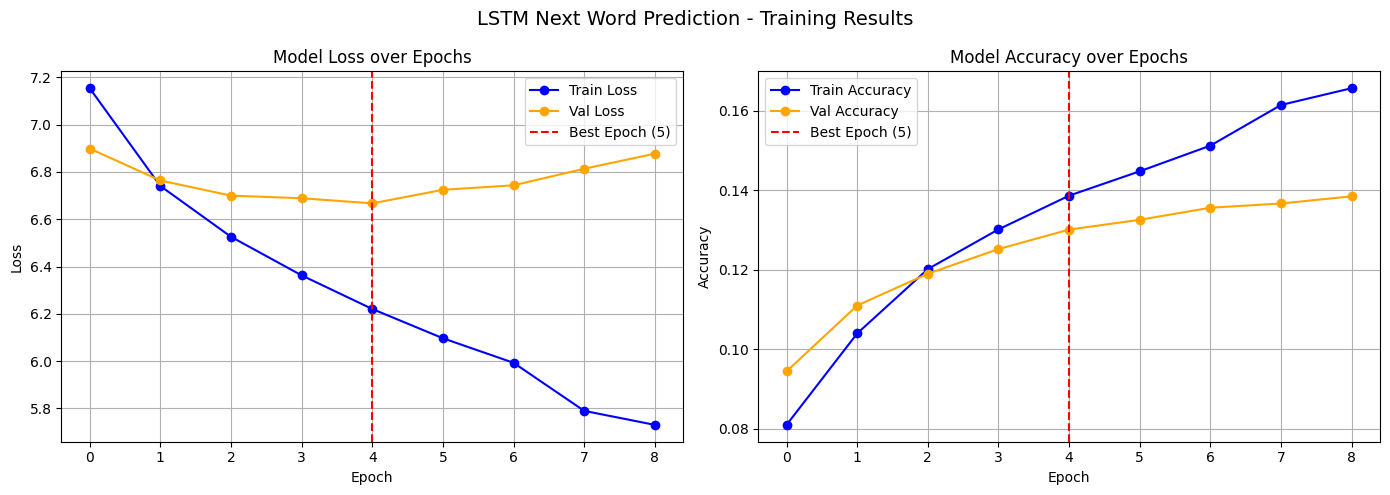

Summary:
  Total Epochs Run : 9
  Best Epoch       : 5
  Final Train Loss : 5.7299
  Final Val Loss   : 6.8775
  Test Loss        : 6.6790
  Test Accuracy    : 12.75%


In [13]:

# Training Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss ---
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', marker='o', color='orange')
axes[0].axvline(x=4, color='red', linestyle='--', label='Best Epoch (5)')
axes[0].set_title('Model Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Accuracy ---
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o', color='orange')
axes[1].axvline(x=4, color='red', linestyle='--', label='Best Epoch (5)')
axes[1].set_title('Model Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('LSTM Next Word Prediction - Training Results', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Total Epochs Run : {len(history.history['loss'])}")
print(f"  Best Epoch       : 5")
print(f"  Final Train Loss : {history.history['loss'][-1]:.4f}")
print(f"  Final Val Loss   : {history.history['val_loss'][-1]:.4f}")
print(f"  Test Loss        : 6.6790")
print(f"  Test Accuracy    : 12.75%")

In [14]:

#  Save Model + Prediction Function

# --- Save model in keras format ---
model.save('next_word_model.keras')
print(" Model saved as next_word_model.keras")

# --- Verify tokenizer is saved ---
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print(" Tokenizer verified and loaded")

# --- Prediction Function ---
def predict_next_word(seed_text, model, tokenizer, seq_length=10, top_k=5):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    # Pad or trim to sequence length
    if len(token_list) < seq_length:
        token_list = [0] * (seq_length - len(token_list)) + token_list
    else:
        token_list = token_list[-seq_length:]

    token_list = np.array(token_list).reshape(1, seq_length)

    # Predict
    predictions = model.predict(token_list, verbose=0)[0]

    # Get top-k predictions
    top_k_indices = predictions.argsort()[-top_k:][::-1]

    results = []
    for idx in top_k_indices:
        word = tokenizer.index_word.get(idx, '')
        prob = predictions[idx]
        results.append((word, round(float(prob), 4)))

    return results

#Test Predictions
print("\n" + "="*50)
print("PREDICTION TEST RESULTS:")
print("="*50)

test_sentences = [
    "the king and queen",
    "machine learning is",
    "the weather is very",
    "he went to the",
    "she said that the"
]

for sentence in test_sentences:
    predictions = predict_next_word(sentence, model, tokenizer)
    print(f"\nInput   : '{sentence}'")
    print(f"Top predictions:")
    for i, (word, prob) in enumerate(predictions, 1):
        print(f"  {i}. '{word}' ({prob*100:.2f}%)")

 Model saved as next_word_model.keras
 Tokenizer verified and loaded

PREDICTION TEST RESULTS:

Input   : 'the king and queen'
Top predictions:
  1. 'and' (3.43%)
  2. 'the' (3.41%)
  3. 'in' (2.36%)
  4. 'a' (1.14%)
  5. 'to' (1.02%)

Input   : 'machine learning is'
Top predictions:
  1. 'a' (7.52%)
  2. 'the' (3.90%)
  3. 'also' (1.76%)
  4. 'not' (1.54%)
  5. 'to' (1.27%)

Input   : 'the weather is very'
Top predictions:
  1. 'a' (2.56%)
  2. 'the' (2.32%)
  3. 'to' (0.86%)
  4. 'not' (0.80%)
  5. 'in' (0.72%)

Input   : 'he went to the'
Top predictions:
  1. 'first' (1.48%)
  2. 'city' (0.82%)
  3. 'film' (0.82%)
  4. 'album' (0.79%)
  5. 'united' (0.72%)

Input   : 'she said that the'
Top predictions:
  1. 'first' (1.46%)
  2. 'city' (0.82%)
  3. 'film' (0.82%)
  4. 'album' (0.79%)
  5. 'united' (0.71%)


In [1]:

from google.colab import files
files.download('next_word_model.keras')
files.download('tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>